# Lab: Discovering Patient Glucose Phenotypes with K-Means

### University of Virginia
### DS 7200: Distributed Computing
### Last Updated: September 29, 2026

---

### Simulated CGM clustering investigation

You are given CGM summary metrics for 200 simulated patients. Your task is to use **K-means clustering** to discover groups of patients with similar glucose profiles.

---

## 1 | Learning objectives

By the end of the lab, you should be able to:

- Explain the basic mechanics of K-means
- Identify why feature standardization is important for distance-based clustering
- Use the elbow method and silhouette score to investigate the choice of `k`
- Fit K-means with MLlib
- Visualize clusters in two dimensions.
- Profile clusters using group summaries.

---

## 2 | Data outline

Each row represents one simulated patient. The variables are derived from CGM summary metrics:

- `mean_glucose_mg_dL`: average glucose
- `glucose_sd_mg_dL`: standard deviation of glucose
- `cv_percent`: coefficient of variation
- `tir_percent`: percentage of time in the target range
- `tbr_percent`: percentage of time below the target range
- `tar_percent`: percentage of time above the target range
- `gmi_percent`: glucose management indicator

The data contain **200 simulated patients**.

In [2]:
# write code to import libraries and read in data

# data_path = '/standard/ds7200-apt4c/large_datasets/simulated_cgm_kmeans_patients.csv'

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("cgm_kmeans").getOrCreate()

data_path = '/home/sabine/projects/distributed_computing/05_clustering_and_dim_reduction/simulated_cgm_kmeans_patients.csv'
df = spark.read.csv(data_path, header=True, inferSchema=True)



Inspect the dataset.

In [3]:
df.printSchema()      # check that inferSchema made the metrics doubles, not strings
df.show(5)
df.describe().show()  # look at the min/max ranges of each column

root
 |-- patient_id: string (nullable = true)
 |-- phenotype: string (nullable = true)
 |-- mean_glucose_mg_dL: double (nullable = true)
 |-- glucose_sd_mg_dL: double (nullable = true)
 |-- cv_percent: double (nullable = true)
 |-- tir_percent: double (nullable = true)
 |-- tbr_percent: double (nullable = true)
 |-- tar_percent: double (nullable = true)
 |-- gmi_percent: double (nullable = true)

+----------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+
|patient_id|        phenotype|mean_glucose_mg_dL|  glucose_sd_mg_dL|        cv_percent|       tir_percent|       tbr_percent|       tar_percent|      gmi_percent|
+----------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+
|      P096|    Hyperglycemic| 182.6251906128119| 36.25540613093743| 19.85235772199871| 37.91626234284356|    

26/09/30 15:54:52 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+----------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|summary|patient_id|        phenotype|mean_glucose_mg_dL|  glucose_sd_mg_dL|        cv_percent|       tir_percent|       tbr_percent|       tar_percent|       gmi_percent|
+-------+----------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|  count|       200|              200|               200|               200|               200|               200|               200|               200|               200|
|   mean|      NULL|             NULL|133.65702510233348| 37.37750577745227|29.500833986072834|  56.8962026892649| 5.831490536195421|37.272306774539686| 6.507076040447819|
| stddev|      NULL|             NULL| 32.48722153050869|13.708200401474983| 12.67568936988705|15.469471296253507| 5.567438456478597|16.8543

---

## 3 | Explore the patient population before clustering

Start by visualizing several pairs of metrics, such as:

- mean glucose vs. TIR
- glucose SD vs. TIR
- TBR vs. TAR

In [ ]:
# write code here
import pandas as pd

pdf = df.toPandas()
pdf.shape

/home/sabine/projects/distributed_computing/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


(200, 9)

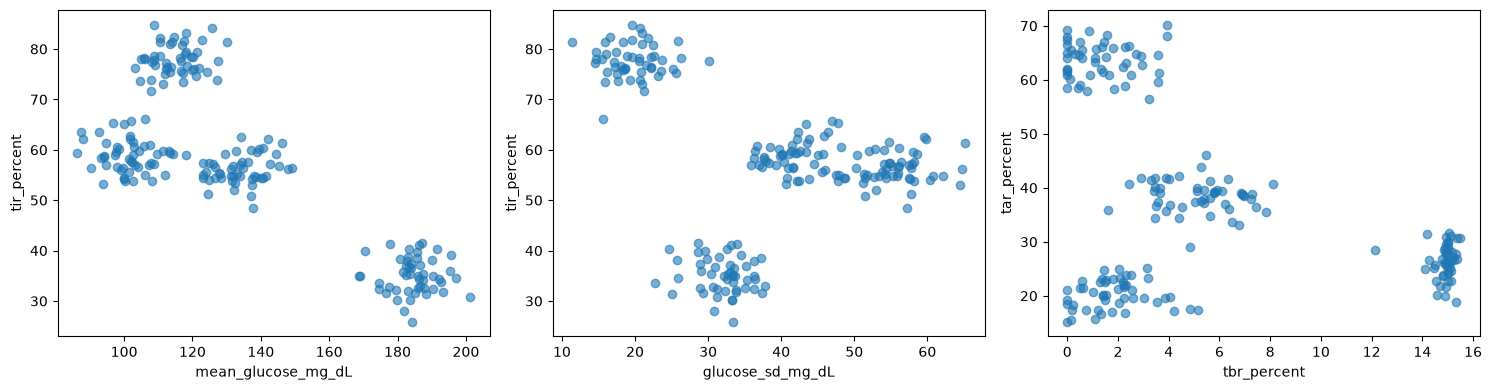

In [12]:
# build 3 plots
pairs = [
    ("mean_glucose_mg_dL", "tir_percent"),
    ("glucose_sd_mg_dL", "tir_percent"),
    ("tbr_percent", "tar_percent"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(pdf[x], pdf[y], alpha=0.6)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
plt.tight_layout()
plt.show()


mean glucose vs TIR: 4 clumps, overall trend slopes down; 2 clumps sit side by side in middle band (TIR $\approx$ 50-65), separated by mean glucose (one around 90-120 and one around 120-150)

glucose sd vs TIR: 4 clumps (2 of which are very close to each other?); no clear overall slope

TBR vs TAR: 4 clumps; one with high TAR and low TBR, one with low TAR and low TBR, one in middle on both axes and one isolated on the right with low TAR and high TBR. No overall slope.

The main point: Each plot is a shadow of 7-dimensional data projected onto 2 dimensions?
- Consider an object's shadown. From one angle two parts cast separate shadows, and from another angle their shadows overlap. Object didn't change, but viewing angle did.
- Groups that differ on the plotted features show up as separate clumps.
- Groups that differ only on features not plotted collapse into one clump.

---

## 4 | Should we scale the data?

K-means uses Euclidean distance. Variables with larger numerical ranges can therefore have disproportionate influence.

First, fit K-means directly to the raw features.

Then repeat the analysis after standardizing every feature to mean 0 and standard deviation 1.

Compare the two solutions.

- Do the cluster assignments change?
- Which features dominate the unscaled solution?

In [ ]:
features = [
    "mean_glucose_mg_dL",
    "glucose_sd_mg_dL",
    "cv_percent",
    "tir_percent",
    "tbr_percent",
    "tar_percent",
    "gmi_percent"
]

# write code here to fit the model

# ASSEMBLE FEATURES
# MLlib models don't read separate columns; they need all features packed into a single vector column (like in mllib_clustering.ipynb)
assembler = VectorAssembler(inputCols=features, outputCol="features")
df_vec = assembler.transform(df)
df_vec.select("patient_id", "features").show(3, truncate=False)

+----------+------------------------------------------------------------------------------------------------------------------------------------+
|patient_id|features                                                                                                                            |
+----------+------------------------------------------------------------------------------------------------------------------------------------+
|P096      |[182.6251906128119,36.25540613093743,19.85235772199871,37.91626234284356,0.0,62.08373765715643,7.678394559458461]                   |
|P016      |[119.83339747847438,18.290989414653865,15.263682578923348,75.79556859627525,2.2461475924401393,21.958283811284602,6.176414867685107]|
|P031      |[113.88955614072918,15.857384988696754,13.923475976236452,81.4469497628134,0.0,18.553050237186604,6.034238182886242]                |
+----------+----------------------------------------------------------------------------------------------------------------

In [9]:
# fit k-means on raw features
# set k value based on what we saw in section 3 (I'm choosing 4)
k = 4

km_raw = KMeans(featuresCol="features", k=k, seed=314)
model_raw = km_raw.fit(df_vec)
pred_raw = model_raw.transform(df_vec)

pred_raw.groupBy("prediction").count().orderBy("prediction").show()

+----------+-----+
|prediction|count|
+----------+-----+
|         0|   50|
|         1|   50|
|         2|   50|
|         3|   50|
+----------+-----+



In [10]:
# now fit after standardizing to mean 0 and standard deviation 1 (definition of a z-score)

scaler = StandardScaler(inputCol="features", outputCol="scaled_features",
                        withMean=True, withStd=True) # withMean=True subtracts that feature's mean first, which moves the center of each feature to 0
                                                   # withStd=True divides by that feature's standard deviation, which puts every feature on the same spread
scaler_model = scaler.fit(df_vec)        # compute each feature's mean and SD
df_scaled = scaler_model.transform(df_vec)

km_scaled = KMeans(featuresCol="scaled_features", k=k, seed=314)
model_scaled = km_scaled.fit(df_scaled)
pred_scaled = model_scaled.transform(df_scaled)

pred_scaled.groupBy("prediction").count().orderBy("prediction").show()

+----------+-----+
|prediction|count|
+----------+-----+
|         0|   50|
|         1|   50|
|         2|   50|
|         3|   50|
+----------+-----+



In [11]:
df_scaled.select("scaled_features").show(1, truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------+
|scaled_features                                                                                                                         |
+----------------------------------------------------------------------------------------------------------------------------------------+
|[1.507305432829719,-0.08185608713409996,-0.7611796078717022,-1.226928831822329,-1.0474279296989006,1.472108181155311,1.5073054328297215]|
+----------------------------------------------------------------------------------------------------------------------------------------+
only showing top 1 row


In [15]:
compare = (pred_raw.select("patient_id", pred_raw.prediction.alias("raw"))
           .join(pred_scaled.select("patient_id", pred_scaled.prediction.alias("scaled")),
                 on="patient_id"))

compare.crosstab("raw", "scaled").show()

+----------+---+---+---+---+
|raw_scaled|  0|  1|  2|  3|
+----------+---+---+---+---+
|         3|  0| 50|  0|  0|
|         0|  0|  0| 50|  0|
|         1| 50|  0|  0|  0|
|         2|  0|  0|  0| 50|
+----------+---+---+---+---+



- Do the cluster assignments change?
    - The assingments didn't change. The groups here are distinct enough that the scaling didn't matter.
- Which features dominate the unscaled solution?

---

## 5 | Choose the number of clusters

Investigate several values of `k`.

Calculate:

- **inertia** (within-cluster sum of squared distances)
- **silhouette score**

Create an elbow plot for `k = 2, ..., 8` and a silhouette-score plot.

What value or values of `k` appear reasonable?

In [18]:
# write code here

---

## 6 | Fit your final model

Choose a value of `k` based on your investigation. Justify your choice.

Then fit K-means using the standardized features.


In [20]:
# write code here to fit the model

---

## 7. Interpret the clusters

Calculate the average CGM metrics for each cluster.

For each cluster:

- Which cluster has the highest mean glucose?
- Which has the highest TBR?
- Give the cluster a **descriptive name** based on the data

In [21]:
# write code here

---

## 8. Visualize the patient phenotypes

Make a scatterplot using two clinically interpretable metrics, such as:

- mean glucose vs. TIR
- CV vs. TIR

Color the points by K-means cluster.

Do the clusters look well separated in this two-dimensional view?

In [22]:
# write code here